In [1]:
# Cell 1: Imports and Setup
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

# Enable seaborn for professional plots
sns.set_style("whitegrid")
# plt.rcParams['font.family'] = 'serif'  # Journal-friendly font
# plt.rcParams['font.serif'] = ['Times New Roman']


regions = ['US-CAL-CISO', 'CA-ON', 'DE', 'AU-QLD', 'NL', 'JP-TK']  # List of regions
base_dirs = ['/home/chad/Desktop/multi-tier-llm-routing-v2/results/US-CAL-CISO_2024_qor_sweep', 
            '/home/chad/Desktop/multi-tier-llm-routing-v2/results/CA-ON_2024_qor_sweep', 
            '/home/chad/Desktop/multi-tier-llm-routing-v2/results/DE_2024_qor_sweep', 
            '/home/chad/Desktop/multi-tier-llm-routing-v2/results/AU-QLD_2024_qor_sweep',
            '/home/chad/Desktop/multi-tier-llm-routing-v2/results/NL_2024_qor_sweep',
            '/home/chad/Desktop/multi-tier-llm-routing-v2/results/JP-TK_2024_qor_sweep'
            ]
# Generate qor values from 0.10 to 0.99 in 0.01 steps
qor_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]

# Machine types and total hours
machine_types = ['0', '1', '2']
total_hours = 8760

# Nested dictionary to hold results: {region: {qor: results_dict}}
all_results = {}

In [2]:
# Cell 2: Data Processing Loop (Extended for Multi-Region)
for region, base_dir in zip(regions, base_dirs):
    results = {}  # Local dict per region
    for qor in qor_values:
        dir_name = f'qor_{qor:.2f}'
        file_path = os.path.join(base_dir, dir_name, 'checkpoint_hour_8760.json')
        
        if not os.path.exists(file_path):
            print(f"Skipping {region} {dir_name}: File not found at {file_path}")
            continue
        
        # Load the JSON data from file
        with open(file_path, 'r') as file:
            data = json.load(file)
        
        # Extract the deployments list
        deployments = data['deployments']
        
        # Initialize dictionaries for calculations
        total_active_counts = {key: 0 for key in machine_types}
        active_hours_count = {key: 0 for key in machine_types}
        
        # Process each deployment entry
        for deployment in deployments:
            machines_per_type = deployment['machines_per_type']
            for typ in machine_types:
                count = machines_per_type[typ]
                total_active_counts[typ] += count
                if count > 0:
                    active_hours_count[typ] += 1
        
        # Additional: Total machine-hours across all types
        total_all_machines = sum(total_active_counts.values())
        
        # Calculations
        time_based_utilization_pct = {}
        average_active_machines = {}
        overall_utilization_pct = {}
        for typ in machine_types:
            time_based_utilization_pct[typ] = (active_hours_count[typ] / total_hours) * 100
            average_active_machines[typ] = total_active_counts[typ] / total_hours
            overall_utilization_pct[typ] = (total_active_counts[typ] / total_all_machines) * 100 if total_all_machines > 0 else 0.0
        
        # Store results
        results[qor] = {
            'time_based': time_based_utilization_pct,
            'avg_active': average_active_machines,
            'overall': overall_utilization_pct
        }
    
    all_results[region] = results

print("Data loading complete for regions:", list(all_results.keys()))

Data loading complete for regions: ['US-CAL-CISO', 'CA-ON', 'DE', 'AU-QLD', 'NL', 'JP-TK']


In [3]:
# Cell 3: Create Unified DataFrame with Regions
# Collect data for DataFrame
data_rows = []
for region in regions:
    if region not in all_results:
        print(f"Warning: No data for region {region}")
        continue
    for qor in sorted(all_results[region].keys()):
        for typ in machine_types:
            data_rows.append({
                'Region': region,
                'QOR': qor,
                'Type': typ,
                'Time-Based Utilization (%)': round(all_results[region][qor]['time_based'][typ], 2),
                'Average Active Machines': round(all_results[region][qor]['avg_active'][typ], 2),
                'Overall Utilization (%)': round(all_results[region][qor]['overall'][typ], 2)
            })

# Create unified DataFrame
region_df = pd.DataFrame(data_rows)

# Display a sample
print("Unified Regional QOR Sweep Results (First 10 rows):")
display(region_df.head(10))

Unified Regional QOR Sweep Results (First 10 rows):


,Region,QOR,Type,Time-Based Utilization (%),Average Active Machines,Overall Utilization (%)
0,US-CAL-CISO,0.1,0,99.79,2.66,20.41
1,US-CAL-CISO,0.1,1,99.67,10.03,77.04
2,US-CAL-CISO,0.1,2,31.75,0.33,2.55
3,US-CAL-CISO,0.2,0,96.75,2.31,18.11
4,US-CAL-CISO,0.2,1,99.66,9.04,70.74
5,US-CAL-CISO,0.2,2,79.45,1.42,11.15
6,US-CAL-CISO,0.3,0,82.85,1.84,14.98
7,US-CAL-CISO,0.3,1,99.63,8.22,66.92
8,US-CAL-CISO,0.3,2,93.21,2.22,18.09
9,US-CAL-CISO,0.4,0,87.31,1.81,14.77


In [4]:
# Cell 4: Pivoted Table for Structured View
# Create pivoted DataFrame with Region/QOR as multi-index and metrics/types as columns
pivot_df = region_df.pivot(index=['Region', 'QOR'], columns=['Type'])

print("Pivoted Regional Results (Condensed View):")
display(pivot_df.head(20))  # Adjust as needed

Pivoted Regional Results (Condensed View):


Time-Based Utilization (%)               Average Active Machines  \
Type                                 0      1      2                       0   
Region QOR                                                                     
AU-QLD 0.10                      99.68  99.69  58.81                    2.10   
       0.20                      80.55  99.68  92.73                    1.38   
       0.30                      68.54  99.67  97.34                    1.27   
       0.40                      69.12  99.66  98.52                    1.22   
       0.50                      72.83  99.65  98.97                    1.16   
       0.60                      78.09  99.57  99.18                    1.33   
       0.70                      76.26  99.54  99.33                    1.40   
       0.80                      69.43  99.57  99.43                    1.38   
       0.90                      70.08  99.57  99.53                    1.45   
       0.99                      91.31  89.66  99.54                    1.98   
CA-ON  0.10                      99.79  99.52  16.67                    3.09   
       0.20                      99.36  99.50  67.37                    3.11   
       0.30                      93.70  99.49  88.22                    2.72   
       0.40                      95.98  99.44  94.78                    2.97   
       0.50                      94.59  99.41  97.04                    3.04   
       0.60                      95.61  99.45  97.99                    3.29   
       0.70                      94.33  99.39  98.62                    3.61   
       0.80                      92.71  99.43  98.92                    3.75   
       0.90                      92.11  99.33  99.05                    4.22   
       0.99                      99.54  99.42  99.14                    5.03   

                        Overall Utilization (%)                
Type            1     2                       0      1      2  
Region QOR                                                     
AU-QLD 0.10  9.91  0.72                   16.51  77.80   5.69  
       0.20  8.99  1.99                   11.14  72.74  16.12  
       0.30  8.21  2.55                   10.58  68.25  21.18  
       0.40  7.54  3.22                   10.21  62.90  26.89  
       0.50  6.86  3.94                    9.72  57.35  32.94  
       0.60  6.19  4.57                   10.98  51.23  37.79  
       0.70  5.51  5.21                   11.54  45.47  42.99  
       0.80  4.80  5.91                   11.45  39.70  48.86  
       0.90  4.14  6.61                   11.86  33.97  54.17  
       0.99  2.84  7.64                   15.91  22.79  61.30  
CA-ON  0.10  9.96  0.17                   23.35  75.38   1.26  
       0.20  8.91  1.09                   23.74  67.95   8.31  
       0.30  8.14  1.87                   21.35  63.93  14.72  
       0.40  7.47  2.46                   23.04  57.91  19.06  
       0.50  6.94  3.04                   23.32  53.32  23.37  
       0.60  6.23  3.66                   24.97  47.26  27.77  
       0.70  5.60  4.21                   26.90  41.72  31.38  
       0.80  4.94  4.83                   27.74  36.51  35.75  
       0.90  4.24  5.44                   30.36  30.50  39.14  
       0.99  3.20  6.25                   34.72  22.10  43.18

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

Plot 1 saved as 'regional_stacked_utilization.pdf'


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

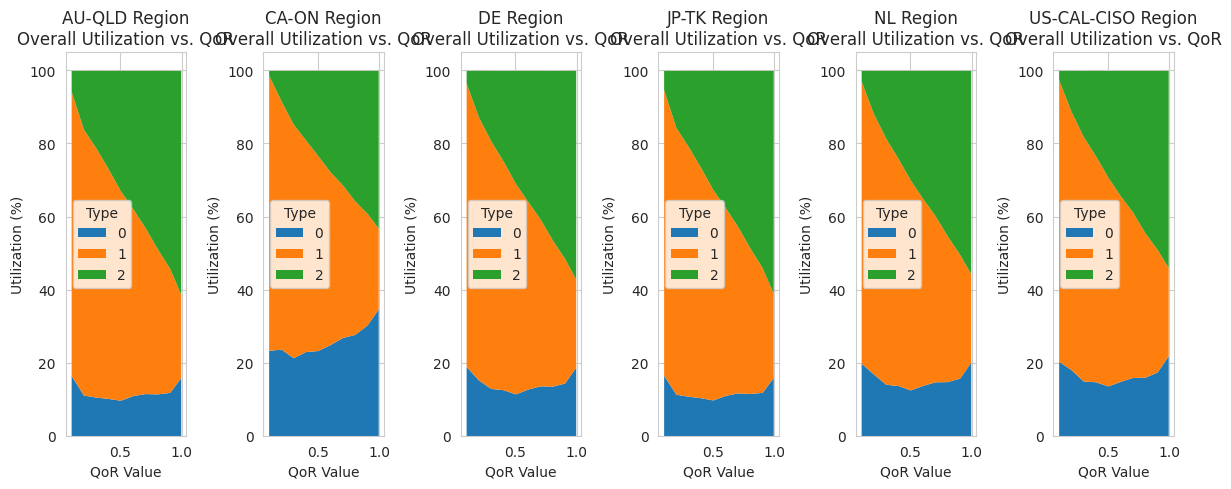

In [5]:
# Cell 5: Plot 1 - Stacked Area Plot (Cumulative Utilization Across Regions)
# Aggregate to total time-based utilization per region-QOR (example metric)
agg_df = region_df.groupby(['Region', 'QOR', 'Type'])['Overall Utilization (%)'].sum().reset_index()
pivot_agg_df = agg_df.pivot_table(values='Overall Utilization (%)', index=['Region', 'QOR'], columns='Type', fill_value=0)

fig, axes = plt.subplots(1, len(regions), figsize=(12, 5))
for idx, region in enumerate(pivot_agg_df.index.get_level_values(0).unique()):
    region_df_slice = pivot_agg_df.loc[region]
    region_df_slice.plot.area(ax=axes[idx], title=f'{region} Region\nOverall Utilization vs. QoR', 
                              xlabel='QoR Value', ylabel='Utilization (%)', linewidth=0)

plt.tight_layout()
plt.savefig('regional_stacked_utilization.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("Plot 1 saved as 'regional_stacked_utilization.pdf'")
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

Plot 2 saved as 'facet_qor_regions.pdf'


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

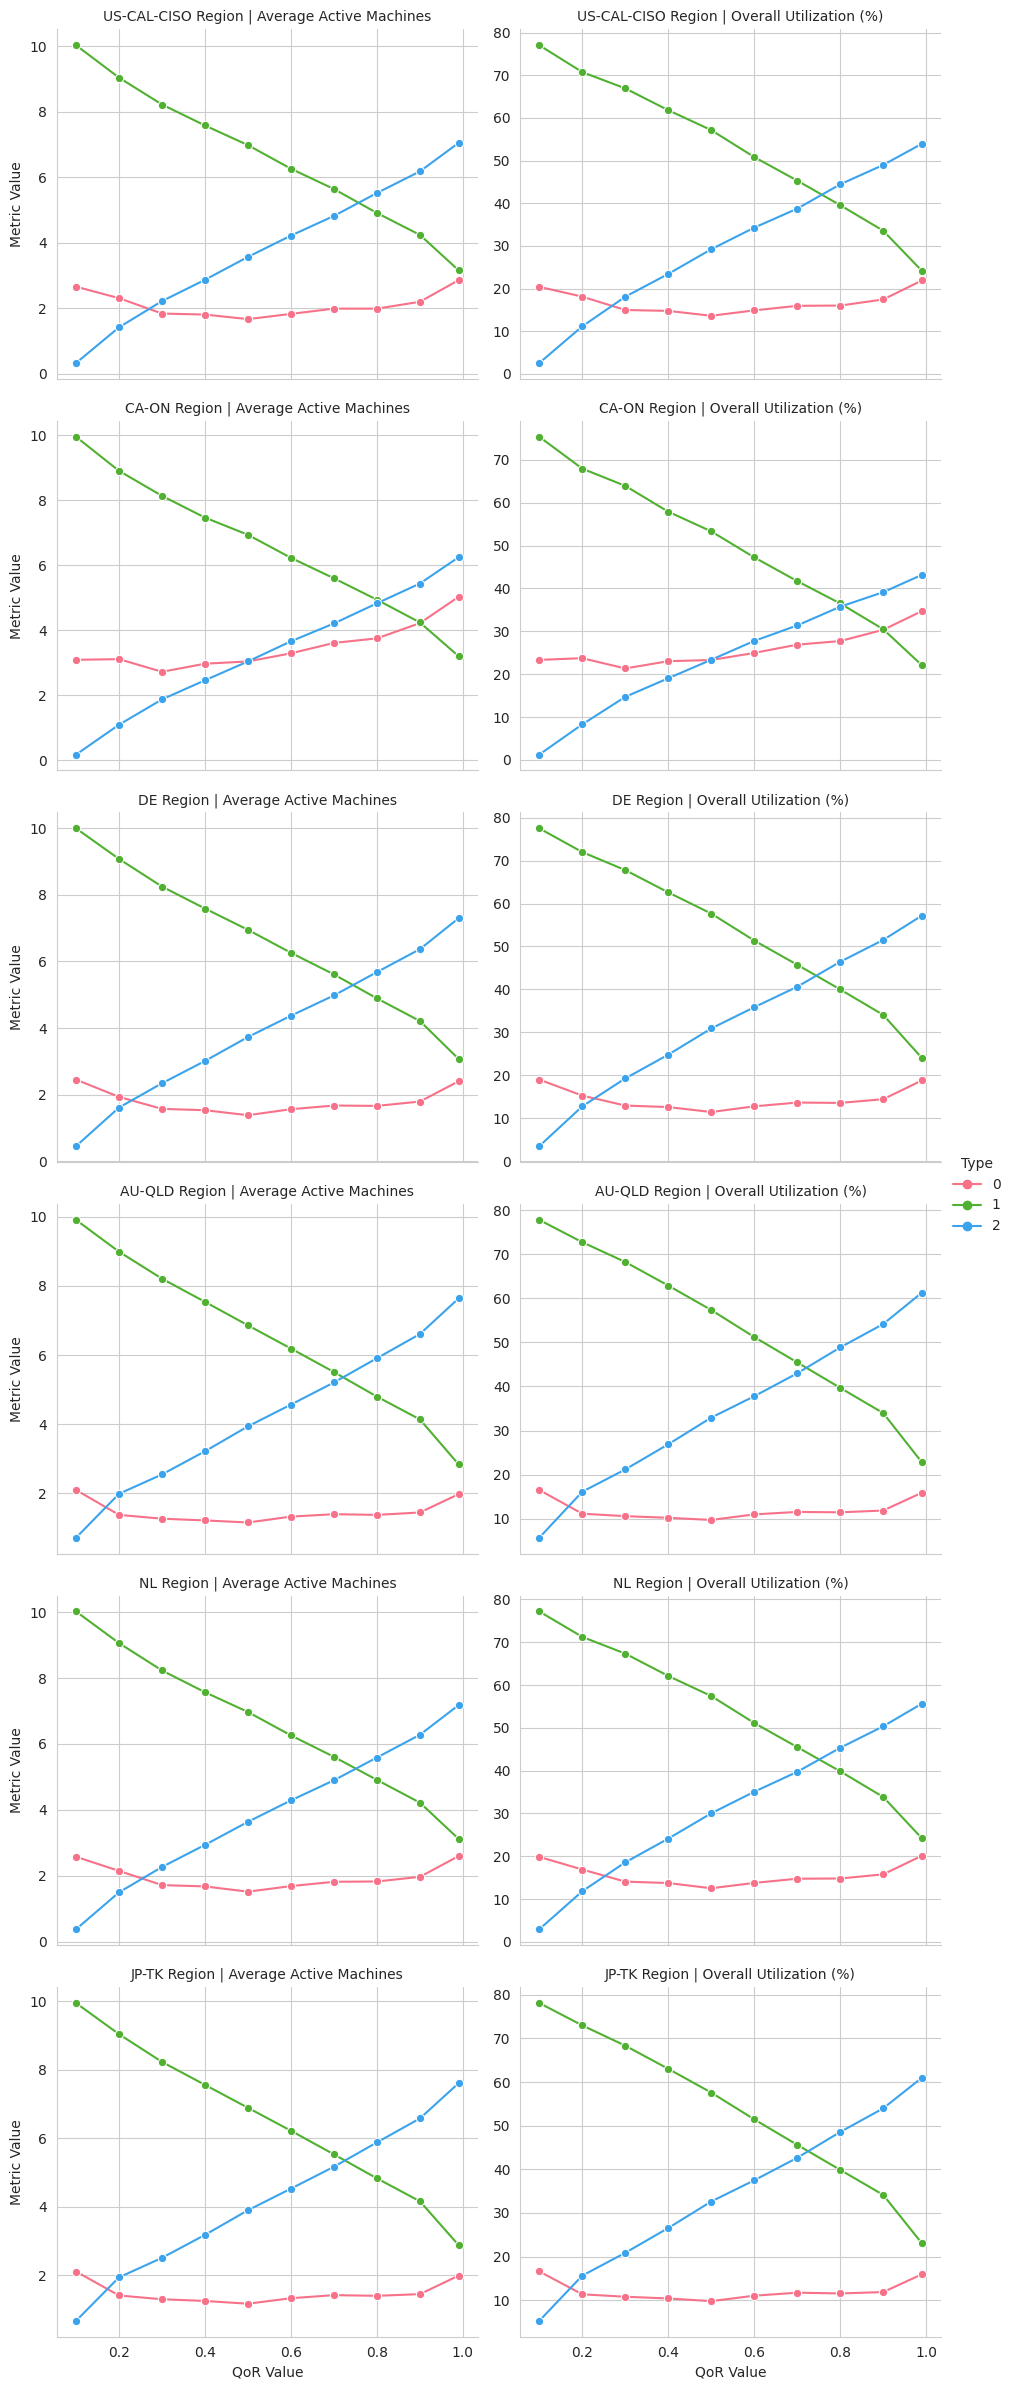

In [6]:
# Cell 6: Plot 2 - Facet Grid Line Plots (QoR Trends Facetted by Region and Metric)
melted_region_df = region_df.melt(id_vars=['Region', 'QOR', 'Type'], 
                                  value_vars=['Average Active Machines', 'Overall Utilization (%)'], 
                                  var_name='Metric', value_name='Value')

g = sns.relplot(data=melted_region_df, x='QOR', y='Value', hue='Type', col='Metric', row='Region', 
                kind='line', marker='o', palette='husl', height=4, aspect=1.2, facet_kws={'sharey': False})
g.set_axis_labels('QoR Value', 'Metric Value')
g.set_titles(row_template='{row_name} Region', col_template='{col_name}')
plt.savefig('facet_qor_regions.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("Plot 2 saved as 'facet_qor_regions.pdf'")
plt.show()

Plot 2 saved as 'facet_qor_regions_ieee.pdf'


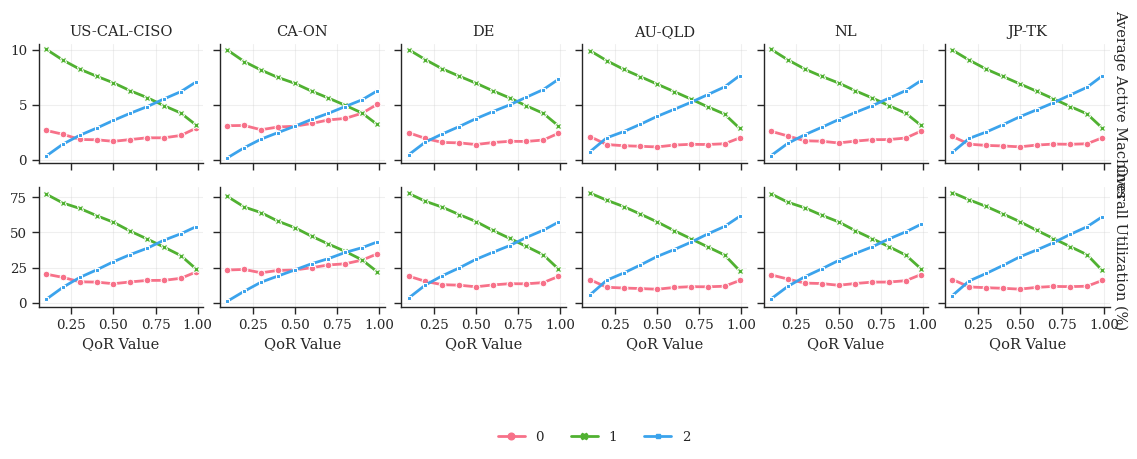

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup IEEE-friendly style (White background, ticks, legible font sizes)
sns.set_theme(context='paper', style='ticks', font_scale=1.1)
plt.rcParams['font.family'] = 'serif' # Matches Times New Roman usually found in IEEE
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# 2. Data Preparation
# Ensure your DataFrame is sorted if necessary so regions appear in logical order
melted_region_df = region_df.melt(id_vars=['Region', 'QOR', 'Type'], 
                                  value_vars=['Average Active Machines', 'Overall Utilization (%)'], 
                                  var_name='Metric', value_name='Value')

# 3. Create the Grid (Regions as Columns, Metrics as Rows)
# Height=2.2 and Aspect=1.0 ensures the total figure fits a double-column width (~7 inches)
g = sns.relplot(
    data=melted_region_df, 
    x='QOR', y='Value', hue='Type', style='Type',
    col='Region',       # Spreads the 6 regions horizontally
    row='Metric',       # Separates the 2 metrics vertically
    kind='line', markers=True, dashes=False,
    palette='husl', 
    height=2.2,         # Height of ONE subplot
    aspect=0.9,         # Width/Height ratio
    linewidth=2,
    facet_kws={'sharey': 'row', 'sharex': True, 'margin_titles': True}
)

# 4. Clean up Axes and Titles
g.set_titles(col_template='{col_name}', row_template='{row_name}')
g.set_axis_labels('QoR Value', '') # Remove Y label to avoid clutter, row title handles it

# 5. Optimize the Layout
# Move Legend to the bottom horizontal center (standard for wide figures)
sns.move_legend(g, "lower center", bbox_to_anchor=(0.5, -0.15), ncol=4, title=None, frameon=False)

# Adjust spacing to prevent overlapping titles/axes
plt.subplots_adjust(wspace=0.1, hspace=0.2)

# 6. Save
# plt.savefig('facet_qor_regions_ieee.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("Plot 2 saved as 'facet_qor_regions_ieee.pdf'")
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

Plot 3 saved as 'radar_qor_regions.pdf' (using Overall Utilization %)


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

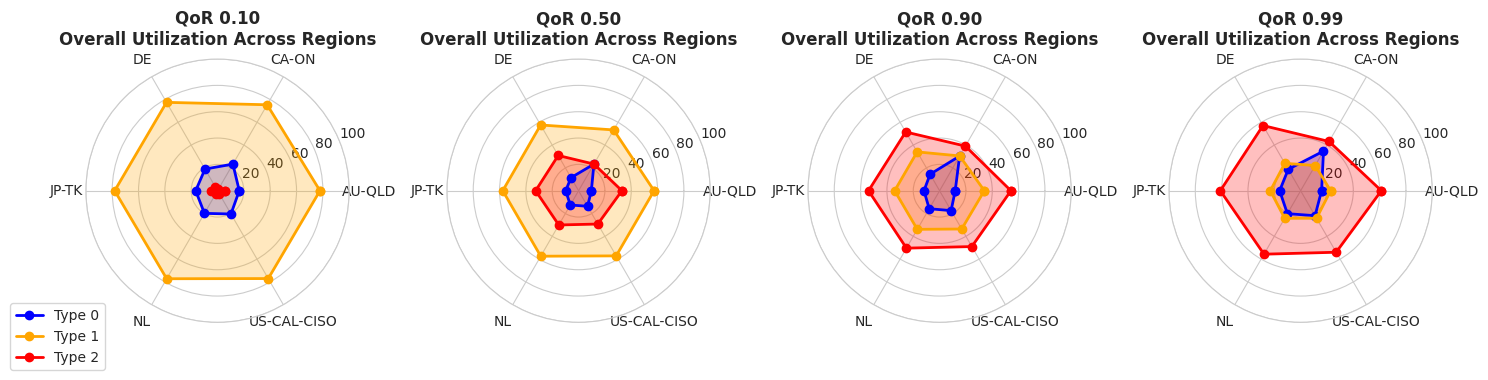

In [7]:
# Cell 7: Plot 3 - Radar/Spider Plot (Multidimensional Comparison at Select QoR Levels)
# Updated to use 'Overall Utilization (%)' (share of total machine-hours across machine types)
select_qors = [0.10, 0.50, 0.90,0.99]  # Selectively compare at low, mid, high QoR
colors = ['blue', 'orange', 'red']  # One per machine type
fig, axes = plt.subplots(1, len(select_qors), figsize=(15, 5), subplot_kw={'projection': 'polar'})

for idx, qor in enumerate(select_qors):
    ax = axes[idx]
    # Changed column name from 'Time-Based Utilization (%)' to 'Overall Utilization (%)'
    qor_data = region_df[region_df['QOR'] == qor].groupby(['Region', 'Type'])['Overall Utilization (%)'].mean().unstack(fill_value=0)
    
    if qor_data.empty:
        print(f"No data for QoR {qor}")
        continue
    
    angles = [n / float(len(qor_data.index)) * 2 * pi for n in range(len(qor_data.index))]
    angles += angles[:1]  # Close the loop
    
    for i, typ in enumerate(machine_types):
        values = qor_data[typ].values.tolist()
        if values:
            values += values[:1]  # Close loop
            ax.plot(angles, values, 'o-', linewidth=2, label=f'Type {typ}', color=colors[i])
            ax.fill(angles, values, alpha=0.25, color=colors[i])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(qor_data.index, fontsize=10)
    ax.set_title(f'QoR {qor:.2f}\nOverall Utilization Across Regions', size=12, fontweight='bold')
    ax.set_rlim(0, 100)  # Assuming 0-100% scale
    if idx == 0:
        ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

plt.tight_layout()
plt.savefig('radar_qor_regions.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("Plot 3 saved as 'radar_qor_regions.pdf' (using Overall Utilization %)")
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found becau

Region DE: Overall relative saving: 22.57 %
Region CA-ON: Overall relative saving: 17.82 %
Region AU-QLD: Overall relative saving: 23.69 %
Region NL: Overall relative saving: 22.08 %
Region JP-TK: Overall relative saving: 23.53 %
Region US-CAL-CISO: Overall relative saving: 21.57 %


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

Plot saved to carbon_savings_plot.pdf


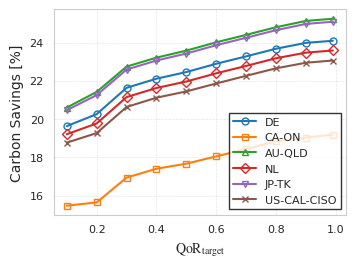

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. IEEE Plotting Style Setup ---
# This block sets the fonts to Times New Roman and sizes to match IEEE standards
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', # Closest match to LaTeX logic
    'font.size': 10,
    'axes.labelsize': 10,       # Size of x/y labels
    'axes.titlesize': 10,       # Size of title (if used)
    'xtick.labelsize': 8,       # Size of tick numbers
    'ytick.labelsize': 8,
    'legend.fontsize': 8,       # Legend text size
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'grid.linewidth': 0.5,
    'grid.linestyle': '--',
    # Single column width is ~3.5 inches. 
    # Height is usually ~2.5 to 3 inches.
    'figure.figsize': (3.5, 2.625) 
})

# Define markers and specific colors for distinction in B&W
markers = ['o', 's', '^', 'D', 'v', 'x']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# --- 2. Data Paths ---
regions = ["DE", "CA-ON", "AU-QLD", "NL", "JP-TK", "US-CAL-CISO"]
base_path_template = "/home/chad/Desktop/multi-tier-llm-routing-v2/results/{region}_2024_qor_sweep_1_in_5m/qor_comparison.csv"
opt_path_template = "/home/chad/Desktop/multi-tier-llm-routing-v2/results/{region}_2024_qor_sweep/qor_comparison.csv"

# --- 3. Processing and Plotting ---
plt.figure() # Size taken from rcParams above

for i, region in enumerate(regions):
    baseline_file = base_path_template.format(region=region)
    optimized_file = opt_path_template.format(region=region)

    if not os.path.exists(baseline_file) or not os.path.exists(optimized_file):
        print(f"Skipping {region}: File not found.")
        continue

    # Load data
    df_base = pd.read_csv(baseline_file)
    df_opt = pd.read_csv(optimized_file)

    # Keep only QoR and total emissions, then merge on QoR target
    cols = ["qor_target", "total_emissions_tCO2e"]
    
    # Pre-sort by qor_target ensures lines don't zigzag if csv is unsorted
    df_base = df_base.sort_values("qor_target")
    df_opt = df_opt.sort_values("qor_target")

    merged = (
        df_base[cols]
        .rename(columns={"total_emissions_tCO2e": "emissions_base"})
        .merge(
            df_opt[cols].rename(
                columns={"total_emissions_tCO2e": "emissions_opt"}
            ),
            on="qor_target",
            how="inner",
        )
    )

    # Calculate Relative savings (%)
    merged["relative_saving_pct"] = (
        (merged["emissions_base"] - merged["emissions_opt"])
        / merged["emissions_base"]
        * 100.0
    )

    # Print summary stats
    overall_saving_pct = (
        (merged["emissions_base"].sum() - merged["emissions_opt"].sum()) 
        / merged["emissions_base"].sum() * 100.0
    )
    print(f"Region {region}: Overall relative saving: {overall_saving_pct:.2f} %")

    # Plot
    plt.plot(
        merged["qor_target"],
        merged["relative_saving_pct"],
        label=region,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)], # vital for B&W printing
        markevery=1,  # Adjust if points are too dense (e.g., set to 5)
        fillstyle='none' # Hollow markers often look cleaner in academic plots
    )

# --- 4. Final Polish ---

# Labels using LaTeX-like formatting for mathematical variables
plt.xlabel(r'$\text{QoR}_{\text{target}}$') 
plt.ylabel("Carbon Savings [%]")

# Ticks and Grid
plt.grid(True, alpha=0.5)
plt.minorticks_on() # Good for technical charts

# Legend
# 'frameon=True' adds a box, standard for IEEE. 
# loc='best' finds the empty spot.
plt.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=0.8)

# Layout adjustment
plt.tight_layout(pad=0.5)

# --- 5. Save Results ---
# Save as PDF for the LaTeX paper (Vector graphics)
output_path = "carbon_savings_plot.pdf"
plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"Plot saved to {output_path}")

# Display
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

Plot saved as 'aggregated_qor_trends.pdf'


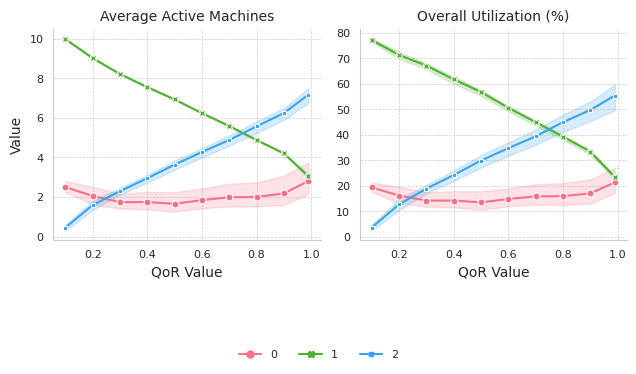

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# ... (Assuming melted_region_df is already created as per your code) ...

# PLOT: Aggregated Trends
# changes: 
# 1. Removed row='Region' (this triggers aggregation)
# 2. Added errorbar='sd' (Optional: uses Standard Deviation instead of Confidence Interval. 
#    'sd' shows the spread of your regions. Default is ('ci', 95) which shows statistical confidence.)
g = sns.relplot(
    data=melted_region_df, 
    x='QOR', 
    y='Value', 
    hue='Type', 
    col='Metric',          # Keep metrics separate side-by-side
    kind='line', 
    style='Type',          # Adds dashed/solid distinction for B&W printing safety
    markers=True, 
    dashes=False,          # Set to True if separate line styles desired
    palette='husl', 
    height=3,              # Reduced height to save vertical space
    aspect=1,              # Square aspect ratio fits columns better
    errorbar=('ci', 95),   # 95% Confidence Interval. Change to 'sd' for Standard Deviation.
    facet_kws={'sharey': False, 'sharex': True}
)

# Formatting for IEEE
g.set_axis_labels('QoR Value', 'Value')
g.set_titles('{col_name}') # Simplified titles

# Clean up the Legend
sns.move_legend(g, "upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, title=None, frameon=False)

plt.tight_layout()
plt.savefig('aggregated_qor_trends.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("Plot saved as 'aggregated_qor_trends.pdf'")
plt.show()

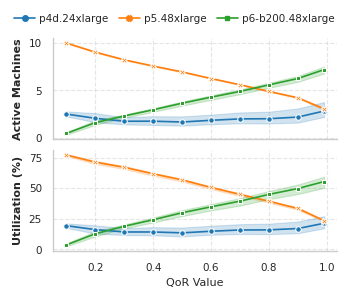

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a safe copy for plotting
plot_df = melted_region_df.copy()
plot_df['Type'] = plot_df['Type'].astype(str)

# Map types
type_mapping = {'0': 'p4d.24xlarge', '1': 'p5.48xlarge', '2': 'p6-b200.48xlarge'}
plot_df['Type'] = plot_df['Type'].replace(type_mapping)

# 2. Setup IEEE Compact Style
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7.5, 
    'ytick.labelsize': 7.5, 
    'legend.fontsize': 7.5,
    'lines.linewidth': 1.2,
    'lines.markersize': 4
})

# 3. Plot: Vertical Stack with reduced height
# aspect * height = width. 
# Target Width ~3.5 inch. 3.5 / 1.3 = ~2.7 aspect ratio
g = sns.relplot(
    data=plot_df, 
    x='QOR', 
    y='Value', 
    hue='Type', 
    row='Metric',            # Vertical stack
    kind='line', 
    style='Type',
    markers=True,
    dashes=False,
    hue_order=['p4d.24xlarge', 'p5.48xlarge', 'p6-b200.48xlarge'],
    style_order=['p4d.24xlarge', 'p5.48xlarge', 'p6-b200.48xlarge'],
    palette='tab10', 
    height=1.3,              # Very short charts (KEY SPACE SAVER)
    aspect=2.6,              # Wide to fill column width
    errorbar=('ci', 95),
    facet_kws={'sharey': False, 'sharex': True, 'legend_out': False}
)

# 4. Aggressive Spacing Management
# hspace=0.1 brings the plots very close together
plt.subplots_adjust(hspace=0.1, top=0.88, bottom=0.12)

# 5. Formatting Axes
titles = ['Active Machines', 'Utilization (%)'] # Short titles
axes = g.axes.flatten()

for i, ax in enumerate(axes):
    # Remove default seaborn title
    ax.set_title("")
    
    # Add compact text label INSIDE the plot or on Y-axis to save header space
    # Here we use the Y-Axis label as the "Title" effectively
    if i == 0:
        ax.set_ylabel(titles[i], fontweight='bold')
    else:
        ax.set_ylabel(titles[i], fontweight='bold')

    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Only show X label on bottom plot
    if i == len(axes) - 1:
        ax.set_xlabel('QoR Value')
    else:
        ax.set_xlabel('')

# 6. Legend: Compact Horizontal Bar at the TOP
# Moving legend to top saves the large margin required at the bottom
sns.move_legend(
    g, "upper center",
    bbox_to_anchor=(0.5, 1), # Places it right above the top plot
    ncol=3, 
    title=None, 
    frameon=False,
    columnspacing=1.0,
    handletextpad=0.4
)

# 7. Force Output Size explicitly for IEEE Column
# 3.5 inches wide, ~2.8 inches tall total
g.fig.set_size_inches(3.5, 2.8)

# plt.savefig('ieee_compact_results.pdf', format='pdf', dpi=300, bbox_inches='tight', pad_inches=0.02)
# print("Compact Plot saved.")
plt.show()